In [1]:
#Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import glob

In [2]:
os.chdir("G:/Meu Drive/DarkMatter/data")

In [8]:
RF_fi = pd.read_csv("RF.csv")
RF_fi.head()

,Feature,Importance
0,RNA_helicase,0.013372
1,Length,0.011387
2,RdRP_1,0.010303
3,TT_ORF1,0.009797
4,Gemini_AL1,0.007560


In [19]:
def min_max_scale(series):
    amplitude = series.max() - series.min()
    if amplitude == 0:
        return series
    return (series - series.min()) / amplitude

RF_fi['Importance_Norm'] = RF_fi["Importance"].transform(min_max_scale)

In [24]:
RF_fi.head()

,Feature,Importance,Importance_Norm
0,RNA_helicase,0.013372,1.000000
1,Length,0.011387,0.851573
2,RdRP_1,0.010303,0.770509
3,TT_ORF1,0.009797,0.732663
4,Gemini_AL1,0.007560,0.565345


In [41]:
THRESHOLD = 0.75
coluna_feature = 'Feature'
coluna_importance = 'Importance'

In [43]:
RF_fi_filtrado = RF_fi[RF_fi['Importance_Norm'] >= THRESHOLD].copy()
RF_fi_filtrado = RF_fi_filtrado.sort_values(by='Importance_Norm', ascending=False)

XGB_fi = pd.read_csv("XGB.csv")  # Ajuste o nome do arquivo se necessário
XGB_fi['Importance_Norm'] = min_max_scale(XGB_fi[coluna_importance])

# Filtra pelo threshold e ordena do maior para o menor
XGB_fi_filtrado = XGB_fi[XGB_fi['Importance_Norm'] >= THRESHOLD].copy()
XGB_fi_filtrado = XGB_fi_filtrado.sort_values(by='Importance_Norm', ascending=False)

In [44]:
XGB_fi.head()

,Feature,Importance,Importance_Norm
0,DNA_pol_viral_C,0.110302,1.000000
1,GP120,0.082986,0.752356
2,Flavi_glycop_C,0.024799,0.224833
3,HN,0.018633,0.168930
4,AATT,0.017192,0.155864


C:\Users\User\AppData\Local\Temp\ipykernel_22908\656128357.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\User\AppData\Local\Temp\ipykernel_22908\656128357.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


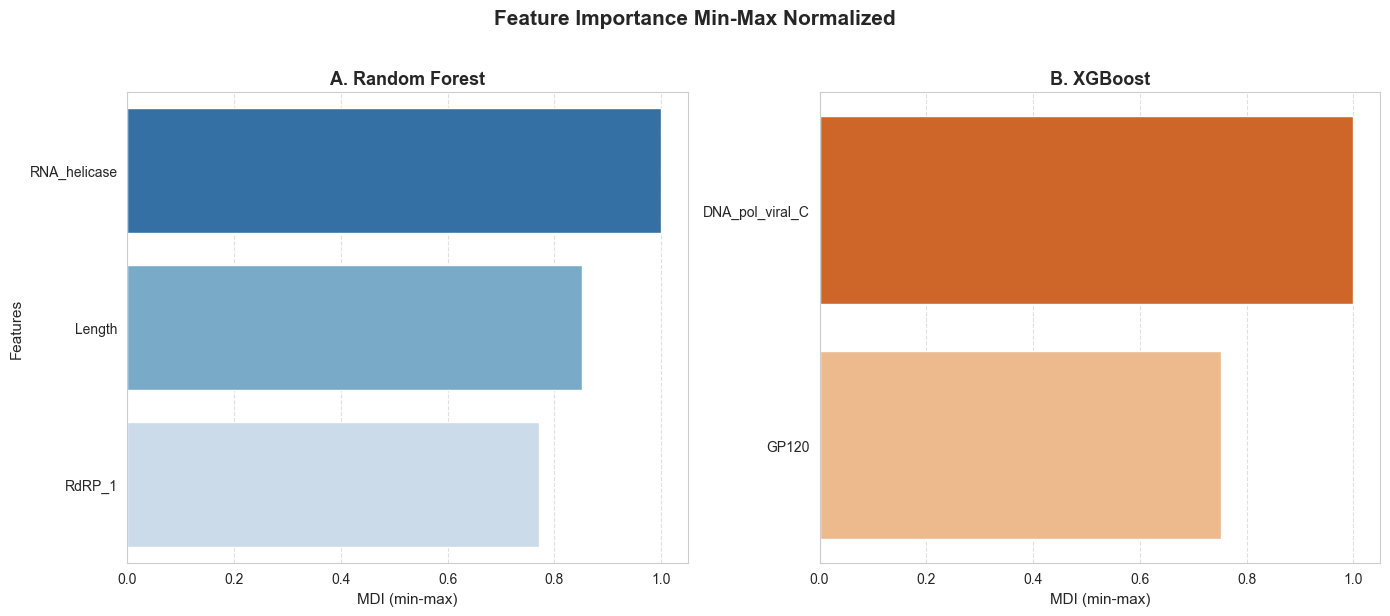

In [55]:
num_features = max(len(RF_fi_filtrado), len(XGB_fi_filtrado))
altura = max(6, num_features * 0.4)

fig, axes = plt.subplots(1, 2, figsize=(14, altura))

sns.barplot(
    data=RF_fi_filtrado,
    x='Importance_Norm',
    y=coluna_feature,
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('A. Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('MDI (min-max)', fontsize=11)
axes[0].set_ylabel('Features', fontsize=11)
axes[0].set_xlim(0, 1.05)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

sns.barplot(
    data=XGB_fi_filtrado,
    x='Importance_Norm',
    y=coluna_feature,
    ax=axes[1],
    palette='Oranges_r'
)
axes[1].set_title('B. XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('MDI (min-max)', fontsize=11)
axes[1].set_ylabel('', fontsize=11)  # Mantém o eixo limpo
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle(f'Feature Importance Min-Max Normalized', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig("FeatureImportanceModel.jpeg", dpi = 350, format = "jpeg")

plt.show()

In [47]:
XGB_fi.to_csv("XGB_FI_MinMax.csv")
RF_fi.to_csv("RF_FI_MinMax.csv")

In [52]:
df_IF = pd.merge(RF_fi, XGB_fi, on="Feature", how="left", suffixes=('_RF', '_XGB'))

In [54]:
df_IF.to_csv("FeatureImportanceNormalized.csv")